In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

In [3]:
train_path = "/kaggle/input/datasets/dhruvtaneja31/rice-grain-classification/classification_224 new/train"
val_path   = "/kaggle/input/datasets/dhruvtaneja31/rice-grain-classification/classification_224 new/train"
test_path  = "/kaggle/input/datasets/dhruvtaneja31/rice-grain-classification/classification_224 new/test"

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [7]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

I0000 00:00:1773336369.361347    1598 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 520ms/step - accuracy: 0.2545 - loss: 1.6261 - val_accuracy: 0.2500 - val_loss: 1.4043 - learning_rate: 0.0010
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 430ms/step - accuracy: 0.2654 - loss: 1.4176 - val_accuracy: 0.2969 - val_loss: 1.3885 - learning_rate: 0.0010
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 431ms/step - accuracy: 0.3194 - loss: 1.3844 - val_accuracy: 0.2344 - val_loss: 1.3847 - learning_rate: 0.0010
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 427ms/step - accuracy: 0.2839 - loss: 1.3842 - val_accuracy: 0.2812 - val_loss: 1.3741 - learning_rate: 0.0010
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 426ms/step - accuracy: 0.3775 - loss: 1.3403 - val_accuracy: 0.2656 - val_loss: 1.3562 - learning_rate: 0.0010
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.3615 - loss: 1.3291 - val_accuracy: 0.2578 - val_loss: 1.3596 - learning_rate: 0.0010
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.3755 - loss: 1.3239 - 

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Found 160 images belonging to 4 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4227 - loss: 1.2718
Test Accuracy: 0.4124999940395355
Test Loss: 1.283434510231018


In [13]:
for layer in base_model.layers[-8:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8
)

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 513ms/step - accuracy: 0.5274 - loss: 1.1225 - val_accuracy: 0.4141 - val_loss: 1.1404
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 436ms/step - accuracy: 0.5904 - loss: 1.0100 - val_accuracy: 0.5078 - val_loss: 1.1080
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 437ms/step - accuracy: 0.6586 - loss: 0.8991 - val_accuracy: 0.5391 - val_loss: 1.0029
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 455ms/step - accuracy: 0.6981 - loss: 0.8365 - val_accuracy: 0.5391 - val_loss: 0.9552
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 441ms/step - accuracy: 0.6604 - loss: 0.8085 - val_accuracy: 0.5156 - val_loss: 0.9925
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 438ms/step - accuracy: 0.7467 - loss: 0.7208 - val_accuracy: 0.6250 - val_loss: 0.8690
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 447ms/step - accuracy: 0.7811 - loss: 0.6118 - val_accuracy: 0.5234 - val_loss: 1.0205
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 426ms/step - accuracy: 0.7618 - loss: 0.6011 - val_accuracy: 0.6797 - 

In [15]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6618 - loss: 0.8495
Test Accuracy: 0.6312500238418579
Test Loss: 0.8694220781326294


In [16]:
model.save("/kaggle/working/rice_classifier_final.keras")

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [18]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


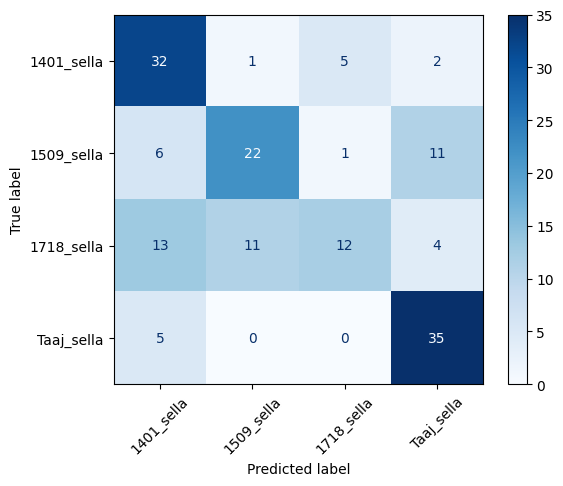

In [52]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Unfreeze last VGG16 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompile model with small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again (fine-tuning phase)
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

In [ ]:
# model.save("/kaggle/working/rice_classifier_finetuned.keras")

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

In [ ]:
# model.save("/kaggle/working/rice_classifier_finetuned.keras")

In [ ]:
# Unfreeze last VGG16 layers
for layer in base_model.layers[-8:]:
    layer.trainable = True

# Recompile model with small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again (fine-tuning phase)
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)